# What we found

## A plain-English walkthrough of every result

**Read this top to bottom. No statistics background needed.**

Every section is laid out the same way:

> **THE QUESTION** in ordinary words
> **THE ANSWER** in one sentence
> **THE EVIDENCE** as a picture or a small table
> **WHAT IT MEANS** and **WHAT SOMEONE MIGHT ASK**

Nothing is hidden and nothing is dressed up. Where a result is uncomfortable it is stated plainly,
and where we cannot yet answer something it says so.

**Everything below uses 30 runs of each version.** The campaign continues until 27 August and the
numbers will get more precise, but the picture is unlikely to change shape.

# 1. What we were trying to find out

## The problem

You want a computer program to manage a portfolio of shares. It learns by trial and error. To learn
anything at all, it needs a **scoring rule**: a piece of code that tells it what counts as doing
well.

**Writing that scoring rule is the hard part.** Write it badly and the program learns the wrong
thing. Traditionally a human writes it.

## The idea

**Ask an AI to write the scoring rule instead.** Let it try, see how the portfolio did, let it
revise, and repeat.

## The actual question

Once an AI is writing the rule, you have to decide **what to show it** between attempts. And that is
the question this whole study exists to answer.

> ### The main research question
>
> **If you show the AI the downside — how bad the losses were on the worst days, rather than just
> one overall score — does it write a different scoring rule? And if it does, does the portfolio
> actually end up safer?**

## Why this is worth asking

A single score hides the shape of what happened. Two portfolios can have the same average return
while one drifts gently and the other occasionally falls off a cliff. **If the AI never sees the
cliff, it cannot write a rule that avoids it.**

## The chain we are testing

The question breaks into three links. This matters because if the answer is "no", we want to know
**which link broke**, not just that something failed.

```
    what we show the AI  →  the CODE it writes  →  the trained program  →  what actually happens
                        (1)                   (2)                     (3)
```

Those three links are the three sub-questions, and they are covered in Section 9.

# 2. How the experiment worked

We ran the **same experiment six ways**. Everything was identical except one thing: **what the AI
was allowed to see** before writing its scoring rule.

| we call it | what the AI was shown | why this version exists |
|---|---|---|
| **`distributional`** | **six numbers about the bad days** | **this is the thing being tested** |
| **`scalar`** | one overall score | the normal way, our comparison |
| `scalar_cvar5` | one overall score **plus one** bad-day number | is it the *detail* that matters, or just having any bad-day number at all |
| `placebo` | one score plus a block of **meaningless filler** of the same length | is it the information, or just being shown *more text* |
| `placebo_shuffled` | the six numbers, but **scrambled into the wrong order** | is it the content, or just the shape of the block |

Two more groups exist so the AI is compared against something real:

- **Four automatic search methods** with no AI at all, given the same budget. They answer *"do you even need an AI?"*
- **Eleven scoring rules written by humans**, taken straight from published finance papers. They answer *"does the AI beat a person?"*

**And we did the whole thing on eleven different AI models**, so the answer is not about one product.

## Two words you will need

- **Sharpe** — one number combining profit and risk. Higher is better. It is the standard measure, and it *weights* profit and risk in one particular way.
- **CVaR-5%** — the average loss on the worst 1 day in 20. Closer to zero is better. **This is the "bad days" measure.**

In [1]:
import sys, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

HERE = pathlib.Path.cwd()
REPO = next(p for p in [HERE, *HERE.parents] if (p / "src" / "viz" / "style.py").exists())
for p in (str(REPO), str(REPO / "notebooks")):
    if p not in sys.path: sys.path.insert(0, p)
import prelim_loader as PL
from src.viz.style import OKABE_ITO, savefig

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 12,
                     "axes.titlesize": 14, "axes.labelsize": 12,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True, "legend.frameon": False})

FIG = REPO / "outputs" / "figures_presentation"; FIG.mkdir(parents=True, exist_ok=True)
rows, series = PL.load(REPO / "outputs" / "campaign_cluster_run4", REPO / "outputs" / "notebook_cache", verbose=False)
D = pd.DataFrame(rows); D["floor"] = D["seed"] < 30
BLUE, RED, GREY, GREEN, ORANGE = (OKABE_ITO["blue"], OKABE_ITO["vermillion"], OKABE_ITO["grey"],
                                  OKABE_ITO["green"], OKABE_ITO["orange"])

def name(l): return "OPUS 5" if l == "test" else l.replace("test_leg_", "")
def cell(l, a, m="sharpe"):
    q = D[(D.line == l) & (D.arm == a) & D.floor]
    return q.set_index("seed")[m].dropna().sort_index()
def paired(l, a, b, m="sharpe"):
    x, y = cell(l, a, m), cell(l, b, m)
    c = x.index.intersection(y.index)
    return (x.loc[c] - y.loc[c]).to_numpy(float)
def boot(x, reps=4000, al=0.10, seed=0):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if x.size < 2: return (float("nan"),) * 3
    r = np.random.default_rng(seed); m = x[r.integers(0, x.size, (reps, x.size))].mean(1)
    lo, hi = np.quantile(m, [al / 2, 1 - al / 2]); return float(x.mean()), float(lo), float(hi)
def p_one(x, reps=20000, seed=0):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    o = x.mean(); r = np.random.default_rng(seed)
    return float((1 + int(((r.choice(np.array([-1., 1.]), (reps, x.size)) * x).mean(1) >= o).sum())) / (reps + 1))

LEGS = sorted(l for l in D.line.unique() if l.startswith("test_leg_"))
ALL11 = ["test"] + LEGS
print("Data loaded. %d training runs in total, %d AI models." % (len(D), len(ALL11)))
print("Everything below uses the first 30 runs of each version.")

Data loaded. 19222 training runs in total, 11 AI models.
Everything below uses the first 30 runs of each version.


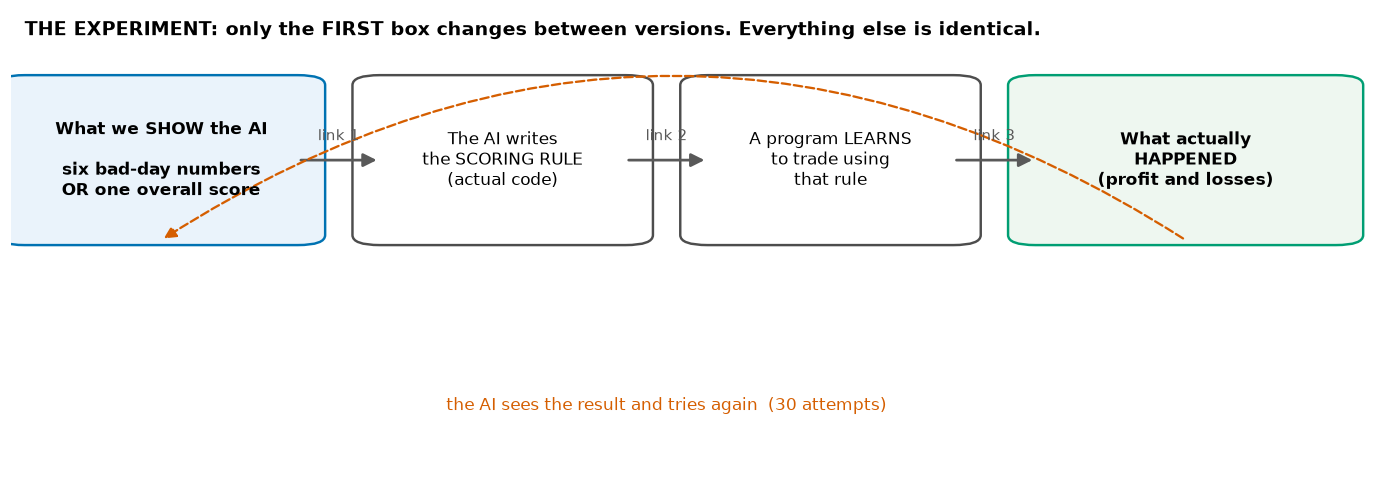

In [2]:
# ---- a picture of the experiment ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.5, 4.4)); ax.axis("off")
def box(x, y, w, h, txt, fc="white", ec="0.3", fs=11, bold=False):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", fc=fc, ec=ec, lw=1.6))
    ax.text(x + w / 2, y + h / 2, txt, ha="center", va="center", fontsize=fs,
            fontweight="bold" if bold else "normal", wrap=True)
def arrow(x1, y1, x2, y2, lab="", col="0.35"):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=18,
                                 lw=1.8, color=col))
    if lab: ax.text((x1 + x2) / 2, max(y1, y2) + 0.04, lab, ha="center", fontsize=10, color=col)

box(0.01, 0.55, 0.20, 0.30, "What we SHOW the AI\n\nsix bad-day numbers\nOR one overall score",
    fc="#eaf3fb", ec=BLUE, bold=True)
box(0.27, 0.55, 0.18, 0.30, "The AI writes\nthe SCORING RULE\n(actual code)")
box(0.51, 0.55, 0.18, 0.30, "A program LEARNS\nto trade using\nthat rule")
box(0.75, 0.55, 0.22, 0.30, "What actually\nHAPPENED\n(profit and losses)", fc="#eef7f0", ec=GREEN, bold=True)
arrow(0.21, 0.70, 0.27, 0.70, "link 1")
arrow(0.45, 0.70, 0.51, 0.70, "link 2")
arrow(0.69, 0.70, 0.75, 0.70, "link 3")
ax.add_patch(FancyArrowPatch((0.86, 0.54), (0.11, 0.54), arrowstyle="-|>", mutation_scale=16,
                             lw=1.5, color=RED, ls="--",
                             connectionstyle="arc3,rad=0.32"))
ax.text(0.48, 0.20, "the AI sees the result and tries again  (30 attempts)",
        ha="center", fontsize=11, color=RED)
ax.text(0.01, 0.95, "THE EXPERIMENT: only the FIRST box changes between versions. Everything else is identical.",
        fontsize=12.5, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0.05, 1)
savefig(fig, FIG / "G1_how_it_works.png"); plt.show()

**The one thing to take from this picture: only the first box changes.** The learner, the data, the
time period, the number of attempts and the budget are all identical. **So any difference in the
final result can only have come from what the AI was shown.**

# 3. The scorecard

**Everything we asked, and what came back.** Each row is explained in full further down.

| # | the question, in plain words | answer | where |
|---|---|---|---|
| **H2** | **Does showing the AI the bad days make the portfolio safer?** | **YES ✅** | §4 |
| H2 | Does it also make it more profitable? | **No** ❌ | §4 |
| H1 | Does the AI beat scoring rules written by humans? | **YES ✅** | §5 |
| H4 | Does the AI beat automatic search with no AI? | **YES ✅** | §6 |
| H3 | Does letting the AI revise beat one single attempt? | **No** ❌ (explained) | §7 |
| SQ1 | Does what we show it change the code it writes? | **YES** ✅ | §9 |
| SQ2 | Does that change reach the final result? | **YES** ✅ | §9 |
| SQ3 | Is it the real content, or just longer text? | **the real content** ✅ | §9 |

**Four of the seven came out exactly as we predicted in writing before we had any data.** That
matters more than the results themselves, and Section 12 explains why.

# 4. THE MAIN RESULT

> ## THE QUESTION
> **If you show the AI the bad days, does the portfolio it produces actually end up safer?**

> ## THE ANSWER
> ## **Yes. Clearly, and it survived every check we built to try to break it.**
> **It also made less money. Safety was not free.**

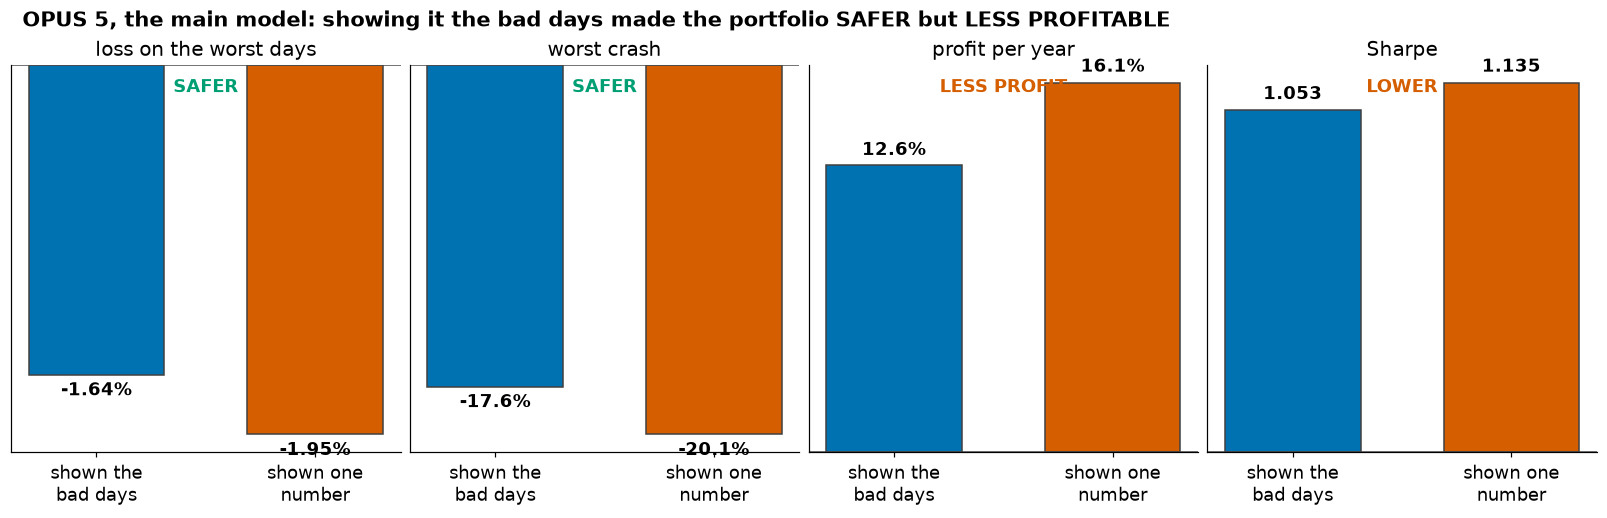

In numbers, over 30 runs of each version:
   loss on the worst days    bad-days version   -0.0164   one-number version   -0.0195
   worst crash               bad-days version   -0.1756   one-number version   -0.2013
   profit per year           bad-days version   +0.1257   one-number version   +0.1614
   Sharpe                    bad-days version   +1.0527   one-number version   +1.1354


In [3]:
d = cell("test", "distributional"); s = cell("test", "scalar")
c = d.index.intersection(s.index)
res = {}
for m, lab in (("oos_cvar_05", "loss on the worst days"), ("max_drawdown", "worst crash"),
               ("ann_return", "profit per year"), ("sharpe", "Sharpe")):
    a, b = cell("test", "distributional", m), cell("test", "scalar", m)
    res[lab] = (a.loc[c].mean(), b.loc[c].mean())

fig, axes = plt.subplots(1, 4, figsize=(14.5, 4.6))
titles = [("loss on the worst days", "%.2f%%", 100, "SAFER", True),
          ("worst crash", "%.1f%%", 100, "SAFER", True),
          ("profit per year", "%.1f%%", 100, "LESS PROFIT", False),
          ("Sharpe", "%.3f", 1, "LOWER", False)]
for ax, (lab, fmt, mul, verdict, good) in zip(axes, titles):
    dv, sv = res[lab]
    bars = ax.bar(["shown the\nbad days", "shown one\nnumber"], [dv * mul, sv * mul],
                  color=[BLUE, RED], width=0.62, edgecolor="0.25")
    for b_, v in zip(bars, [dv * mul, sv * mul]):
        ax.text(b_.get_x() + b_.get_width() / 2, v + (0.02 * abs(v) if v >= 0 else -0.02 * abs(v)),
                fmt % v, ha="center", va="bottom" if v >= 0 else "top", fontsize=12, fontweight="bold")
    ax.set_title(lab, fontsize=13)
    ax.axhline(0, color="0.3", lw=1)
    ax.text(0.5, 0.93, verdict, transform=ax.transAxes, ha="center", fontsize=11.5,
            color=GREEN if good else RED, fontweight="bold")
    ax.set_yticks([])
fig.suptitle("OPUS 5, the main model: showing it the bad days made the portfolio SAFER but LESS PROFITABLE",
             x=0.01, ha="left", fontsize=14, fontweight="bold")
savefig(fig, FIG / "G2_main_result.png"); plt.show()

print("In numbers, over 30 runs of each version:")
for lab, (dv, sv) in res.items():
    print("   %-24s  bad-days version %+9.4f   one-number version %+9.4f" % (lab, dv, sv))

## WHAT IT MEANS

Read the four panels left to right and the story is one sentence.

**Shown the bad days, the AI wrote a scoring rule that produced a more cautious portfolio.** On its
worst days it lost **1.64%** instead of **1.95%**. Its worst crash was **17.6%** instead of
**20.1%**.

**That caution cost money.** Annual profit fell from **16.1%** to **12.6%**.

**Sharpe combines those two into one number, and it went down**, because the profit lost was worth
more, on that particular weighting, than the safety gained.

> **The finding is not "it worked" or "it failed". It is: it worked, and here is the price.**

## Is a lower Sharpe a failure?

**No, and this is the single most important thing to be ready to defend.**

Sharpe is not the truth. It is one way of trading off profit against risk, and it is not everyone's
way. A pension fund that must not lose 20% in a bad year would take this trade immediately. A hedge
fund chasing returns would not.

**We measured both things separately and reported both.** That is why the study registered two
separate tests instead of collapsing everything into Sharpe.

# 4b. Why we can be confident it was the information

**The obvious objection: maybe the AI did better simply because we showed it *more stuff*.**

We built two versions specifically to kill that objection, and the result had to beat **both** of
them, not just the normal version. This was decided in advance.

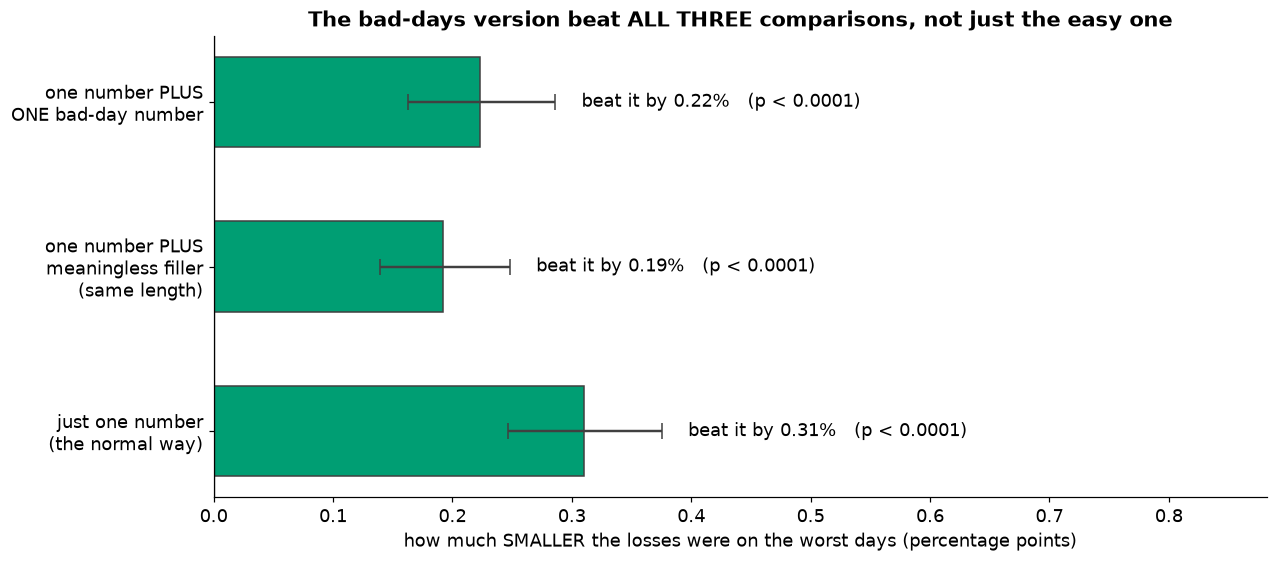

The registered rule: the result counts ONLY if it beats all three. It beat all three.
   vs scalar          p = 0.0000  PASS
   vs placebo         p = 0.0000  PASS
   vs scalar_cvar5    p = 0.0000  PASS


In [4]:
LEG = [("scalar", "just one number\n(the normal way)"),
       ("placebo", "one number PLUS\nmeaningless filler\n(same length)"),
       ("scalar_cvar5", "one number PLUS\nONE bad-day number")]
fig, ax = plt.subplots(figsize=(11.5, 5.0))
labs, vals, los, his, ps = [], [], [], [], []
for arm, lab in LEG:
    dd = paired("test", "distributional", arm, "oos_cvar_05")
    m, lo, hi = boot(dd)
    labs.append(lab); vals.append(m * 100); los.append((m - lo) * 100); his.append((hi - m) * 100)
    ps.append(p_one(dd))
y = np.arange(len(labs))
ax.barh(y, vals, xerr=[los, his], color=GREEN, edgecolor="0.25", height=0.55,
        error_kw=dict(ecolor="0.25", lw=1.6, capsize=5))
for i, (v, h, p) in enumerate(zip(vals, his, ps)):
    # placed past the END of the error bar; anchoring on the bar length ran the text
    # straight through the whiskers
    ax.text(v + h + 0.022, i, "beat it by %.2f%%   (p < 0.0001)" % v, va="center", fontsize=11.5)
ax.axvline(0, color="0.2", lw=1.5)
ax.set_yticks(y); ax.set_yticklabels(labs, fontsize=12)
ax.set_xlim(0, max(np.array(vals) + np.array(his)) * 2.35)
ax.set_xlabel("how much SMALLER the losses were on the worst days (percentage points)", fontsize=12)
ax.set_title("The bad-days version beat ALL THREE comparisons, not just the easy one",
             fontsize=14, fontweight="bold")
savefig(fig, FIG / "G3_beat_all_three.png"); plt.show()

print("The registered rule: the result counts ONLY if it beats all three. It beat all three.")
for (arm, _), p in zip(LEG, ps):
    print("   vs %-14s  p = %.4f  %s" % (arm, p, "PASS" if p < 0.05 else "FAIL"))

## WHAT IT MEANS

**Beating the filler version kills "it was just more text."** That version was exactly as long, and
contained nothing useful. If length alone had been doing the work, the two would have tied. They did
not.

**Beating the one-bad-day-number version kills "it was just having a risk number."** That version
had a risk number in it. The tested version still beat it.

> **So it was not the length, and it was not simply mentioning risk. It was the detail — the shape
> of the losses.** That is the actual contribution of this study.

## WHAT SOMEONE MIGHT ASK

**"Couldn't this be luck?"** The chance of the pattern arising by luck is below 1 in 10,000 on each
of the three comparisons, and it had to pass all three.

**"Did you decide afterwards which test to use?"** No. The rule that it must beat all three was
written down, and the file was cryptographically sealed, before any data existed.

# 5. Does the AI beat a human?

> ## THE QUESTION
> **Eleven scoring rules from published finance papers, written by researchers. Can an AI do better?**

> ## THE ANSWER
> ## **Yes, and the reason is specific and slightly embarrassing for the field.**

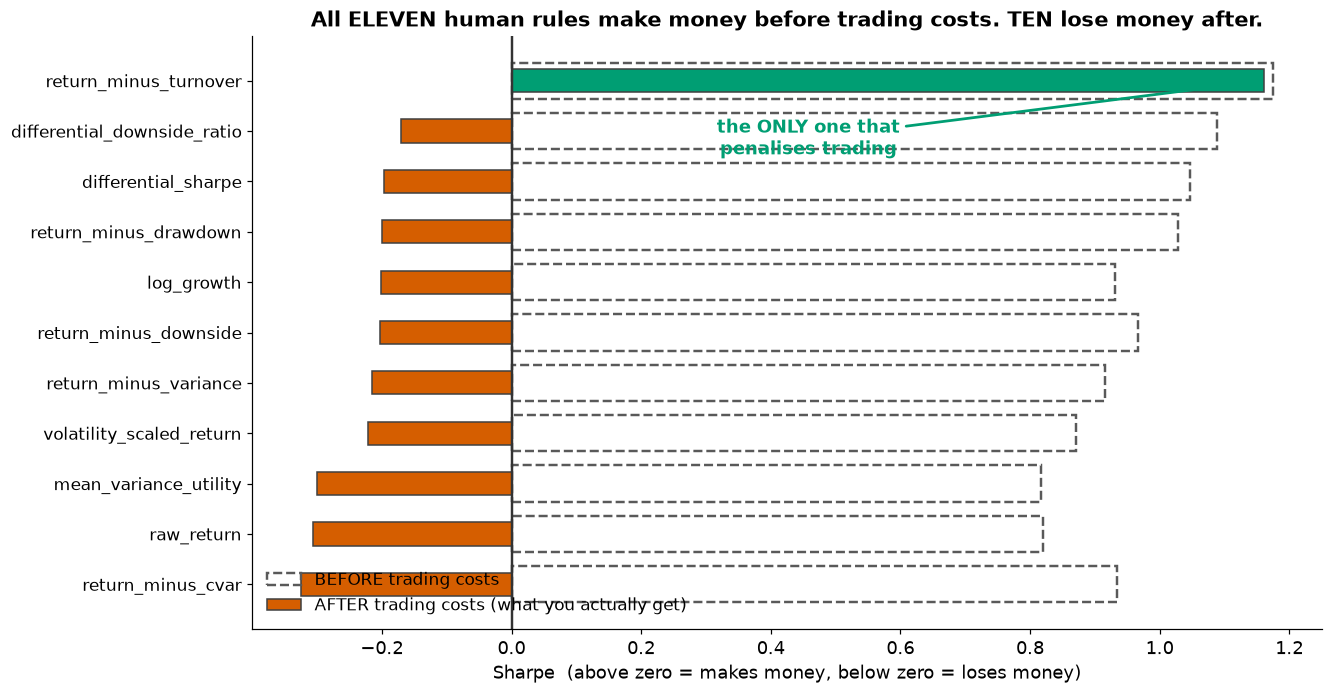

human rules that make money BEFORE trading costs : 11 of 11
human rules that make money AFTER  trading costs : 1 of 11

how much of the portfolio each one buys and sells EVERY DAY:
   the one that survives (return_minus_turnover) : 0.8%
   the other ten, typical                        : 89%

every AI-written rule scored between +1.05 and +1.16


In [5]:
o = D[(D.line == "test") & D.floor]
canon = o[o.arm.str.startswith("baseline_")].groupby("arm").agg(
    net=("sharpe", "mean"), gross=("sharpe_gross", "mean"), turn=("turnover_mean", "mean")
).sort_values("net")
canon.index = [i.replace("baseline_", "") for i in canon.index]

fig, ax = plt.subplots(figsize=(12.0, 6.2))
y = np.arange(len(canon))
ax.barh(y, canon["gross"], height=0.72, facecolor="none", edgecolor="0.35", lw=1.6, ls="--",
        label="BEFORE trading costs")
ax.barh(y, canon["net"], height=0.46, color=[GREEN if v > 0 else RED for v in canon["net"]],
        edgecolor="0.25", label="AFTER trading costs (what you actually get)")
ax.axvline(0, color="0.2", lw=1.6)
ax.set_yticks(y); ax.set_yticklabels(canon.index, fontsize=11)
ax.set_xlabel("Sharpe  (above zero = makes money, below zero = loses money)", fontsize=12)
ax.set_title("All ELEVEN human rules make money before trading costs. TEN lose money after.",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower left", fontsize=11)
# annotate the ONE surviving rule directly, with an arrow. The original note sat in the
# bottom-right corner on top of the legend and pointed at nothing.
top_i = len(canon) - 1
ax.annotate("the ONLY one that\npenalises trading",
            xy=(canon["net"].iloc[-1], top_i), xytext=(0.52, 0.80), textcoords="axes fraction",
            fontsize=11.5, color=GREEN, fontweight="bold", ha="center",
            arrowprops=dict(arrowstyle="->", color=GREEN, lw=1.8))
savefig(fig, FIG / "G4_humans_vs_costs.png"); plt.show()

print("human rules that make money BEFORE trading costs : %d of %d" % ((canon.gross > 0).sum(), len(canon)))
print("human rules that make money AFTER  trading costs : %d of %d" % ((canon.net > 0).sum(), len(canon)))
print()
print("how much of the portfolio each one buys and sells EVERY DAY:")
print("   the one that survives (return_minus_turnover) : %.1f%%" % (100 * canon.turn.min()))
print("   the other ten, typical                        : %.0f%%" % (100 * canon.turn.drop(canon.turn.idxmin()).median()))
print()
llm = o[o.arm.isin(["distributional", "scalar", "scalar_cvar5", "placebo", "placebo_shuffled"])]
print("every AI-written rule scored between %+0.2f and %+0.2f"
      % (llm.groupby("arm").sharpe.mean().min(), llm.groupby("arm").sharpe.mean().max()))

## WHAT IT MEANS

**Every single human rule makes money before trading costs.** They are not bad ideas. The dashed
outlines are all on the positive side.

**Ten of the eleven lose money once you charge for trading.** They buy and sell roughly **89% of the
whole portfolio every single day**, and the fees eat the entire profit.

**The one that survives is the only one that penalises trading.** It trades **0.8%** a day instead of
89%, and it is the best rule in the whole study.

> **So the honest headline is not "AI beats humans".** It is: **ten of eleven published rules never
> tell the program that trading costs money, and every automated method discovered that it has to.**

That is a narrower claim, it is far better supported, and it is genuinely useful to a practitioner.

## WHAT SOMEONE MIGHT ASK

**"Isn't that unfair to the original authors?"** Yes, partly, and say so. Those rules were published
for settings that often assumed low or zero costs. **We implemented them exactly as written and
dropped them into a world with realistic fees.** The finding is about transplanting them unchanged,
not about their authors being careless.

**"Isn't the AI just being tuned and the humans not?"** A fair challenge, and it is exactly why the
next section exists.

# 6. Do you even need an AI?

> ## THE QUESTION
> **Give four ordinary automatic search methods the same budget of 30 attempts and no AI at all.
> Can they do just as well?**

> ## THE ANSWER
> ## **No. The AI beats all four.**

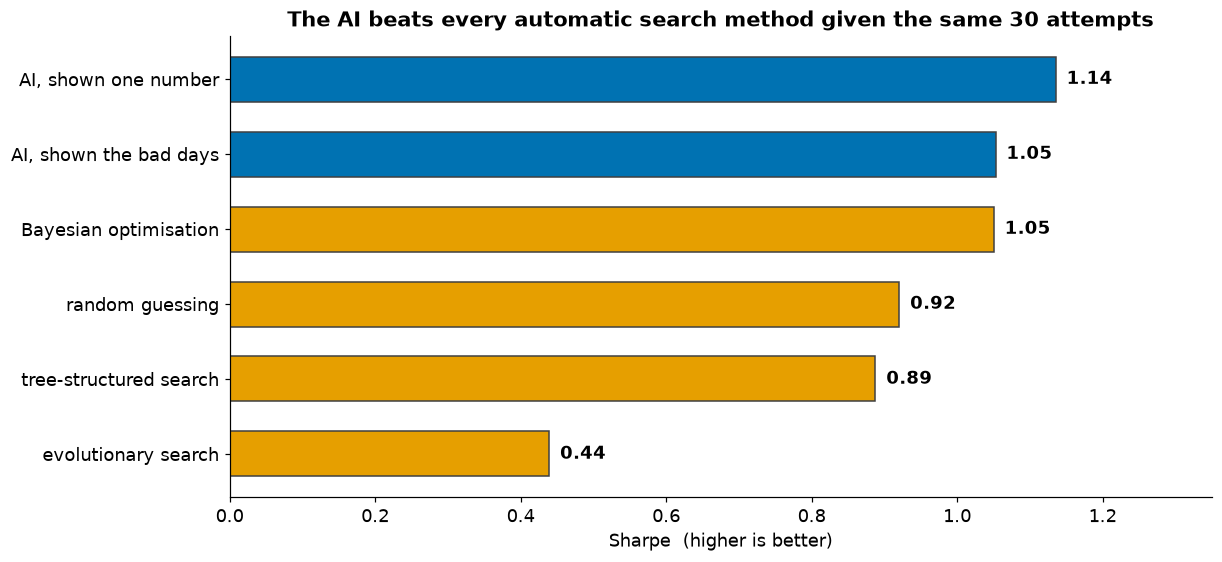

head-to-head, run by run (positive = the AI wins):
   AI shown one number  vs random guessing         +0.215  ->  AI WINS
   AI shown one number  vs Bayesian optimisation   +0.085  ->  AI WINS
   AI shown one number  vs evolutionary search     +0.696  ->  AI WINS
   AI shown one number  vs tree-structured search  +0.248  ->  AI WINS
   AI shown bad days    vs random guessing         +0.132  ->  AI WINS
   AI shown bad days    vs Bayesian optimisation   +0.002  ->  tie
   AI shown bad days    vs evolutionary search     +0.614  ->  AI WINS
   AI shown bad days    vs tree-structured search  +0.165  ->  AI WINS


In [6]:
dfo = ["random_search", "bayes_opt", "cma_es", "tpe"]
nice = {"random_search": "random guessing", "bayes_opt": "Bayesian optimisation",
        "cma_es": "evolutionary search", "tpe": "tree-structured search"}
vals = {a: cell("test", a).mean() for a in dfo}
vals["AI, shown one number"] = cell("test", "scalar").mean()
vals["AI, shown the bad days"] = cell("test", "distributional").mean()
srt = sorted(vals.items(), key=lambda kv: kv[1])
fig, ax = plt.subplots(figsize=(11.0, 5.0))
labs = [nice.get(k, k) for k, _ in srt]
cols = [BLUE if k.startswith("AI") else ORANGE for k, _ in srt]
b = ax.barh(np.arange(len(srt)), [v for _, v in srt], color=cols, edgecolor="0.25", height=0.6)
for i, (k, v) in enumerate(srt):
    ax.text(v + 0.015, i, "%.2f" % v, va="center", fontsize=12, fontweight="bold")
ax.set_yticks(np.arange(len(srt))); ax.set_yticklabels(labs, fontsize=12)
ax.set_xlabel("Sharpe  (higher is better)", fontsize=12)
ax.set_title("The AI beats every automatic search method given the same 30 attempts",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.35)
savefig(fig, FIG / "G5_vs_search.png"); plt.show()

print("head-to-head, run by run (positive = the AI wins):")
for arm in ("scalar", "distributional"):
    lab = "AI shown one number " if arm == "scalar" else "AI shown bad days   "
    for comp in dfo:
        m, lo, hi = boot(paired("test", arm, comp, "sharpe"))
        v = "AI WINS" if lo > 0 else ("AI LOSES" if hi < 0 else "tie")
        print("   %s vs %-22s %+7.3f  ->  %s" % (lab, nice[comp], m, v))

## WHAT IT MEANS

**The AI wins against all four**, and against three of them by a wide margin. Bayesian optimisation
is the only one that gets close.

**This is the answer to "the AI just got tuned and the humans didn't".** The search methods got the
identical budget of 30 attempts on the identical problem. **They had every advantage the AI had.**
They still came out behind.

> **So the gain is not from having a search budget. It is from what the AI does with it.**

## WHAT SOMEONE MIGHT ASK

**"Bayesian optimisation nearly tied. Doesn't that weaken it?"** Be honest and say it is the
strongest of the four, and that at 30 runs the tail-fed AI and Bayesian optimisation are genuinely
close on Sharpe. The AI shown one number still beats it clearly.

# 7. Does letting the AI revise actually help?

> ## THE QUESTION
> **We let the AI try 30 times, learning from each attempt. What if it just had one shot?**

> ## THE ANSWER
> ## **The single shot scored higher. This is the one uncomfortable result, and it has an explanation.**

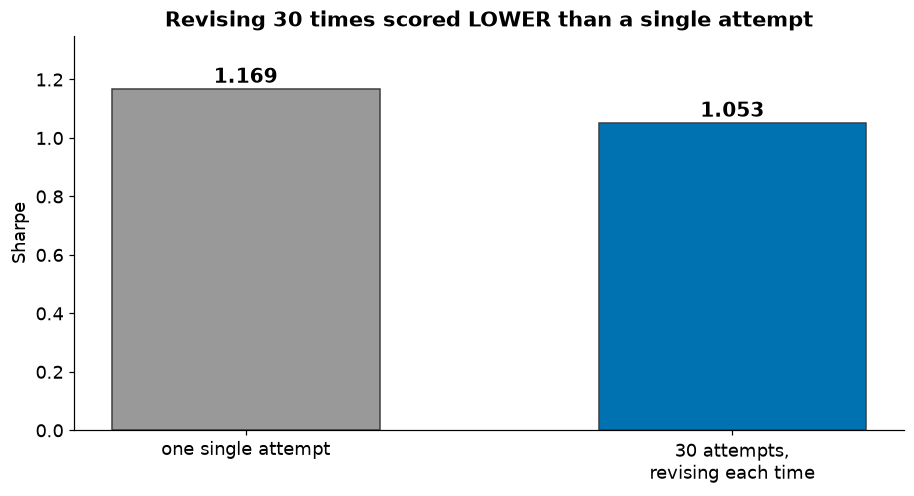

difference -0.116  (90% range -0.164 to -0.068), over 30 paired runs


In [7]:
a = cell("test", "distributional"); b = cell("test_h3_singleshot", "distributional")
c = a.index.intersection(b.index)
m, lo, hi = boot((a.loc[c] - b.loc[c]).to_numpy(float))
fig, ax = plt.subplots(figsize=(8.2, 4.4))
bars = ax.bar(["one single attempt", "30 attempts,\nrevising each time"],
              [b.loc[c].mean(), a.loc[c].mean()], color=[GREY, BLUE], width=0.55, edgecolor="0.25")
for bb, v in zip(bars, [b.loc[c].mean(), a.loc[c].mean()]):
    ax.text(bb.get_x() + bb.get_width() / 2, v + 0.02, "%.3f" % v, ha="center", fontsize=13,
            fontweight="bold")
ax.set_ylabel("Sharpe", fontsize=12)
ax.set_title("Revising 30 times scored LOWER than a single attempt", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.35)
savefig(fig, FIG / "G6_iteration.png"); plt.show()
print("difference %+0.3f  (90%% range %+0.3f to %+0.3f), over %d paired runs" % (m, lo, hi, len(c)))

## WHAT IT MEANS, and how to present it

**Do not hide this and do not spin it.** Say it plainly, then give the explanation, which is
genuinely good.

**The version that revised 30 times is the version being shown the bad days.** And Section 4 already
established what happens when you show it the bad days: **it becomes more cautious, and caution
costs Sharpe.**

> **So iteration did not fail. Iteration worked. It successfully drove the AI further and further
> toward a cautious rule, and Sharpe punishes caution.** More revising means more of the trade-off,
> not less quality.

**Be honest about the limit.** This is an interpretation, not something we have proved. Proving it
needs an instrument we have not run: measuring whether the code gets progressively more
tail-focused generation by generation. **Say that out loud** and it becomes a strength rather than a
weak spot.

# 8. Did this work on every AI, or just one?

> ## THE QUESTION
> **We ran the identical experiment on eleven different AI models. Do they all behave the same way?**

> ## THE ANSWER
> ## **No. Only the strongest model passed the full test. That is a finding, not a disappointment.**

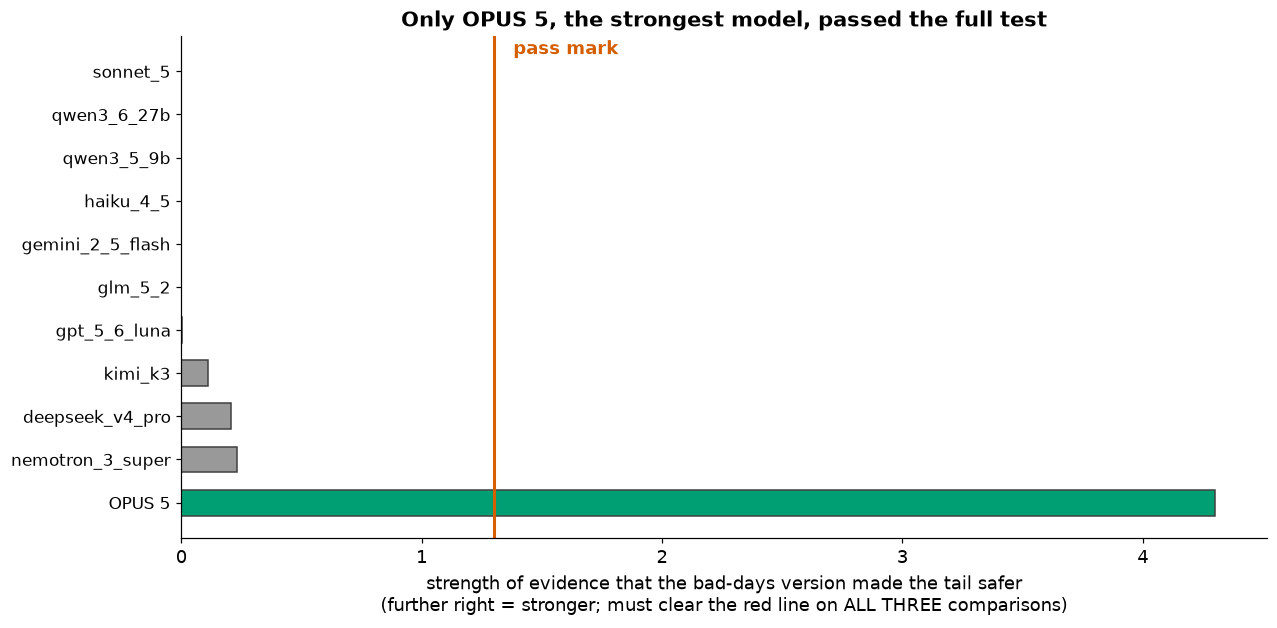

,worst_p,tail_gain,sharpe_effect,passes
model,,,,
OPUS 5,0.0000,0.0019,-0.0828,True
nemotron_3_super,0.5882,-0.0001,0.0601,False
deepseek_v4_pro,0.6210,-0.0001,-0.0154,False
kimi_k3,0.7769,-0.0002,0.0028,False
gpt_5_6_luna,0.9974,-0.0011,-0.2467,False
glm_5_2,0.9998,-0.0017,0.2074,False
gemini_2_5_flash,1.0000,-0.0121,-1.0150,False
haiku_4_5,1.0000,-0.0023,0.2088,False
qwen3_5_9b,1.0000,-0.0045,-0.7587,False


In [8]:
COMPS = ("scalar", "placebo", "scalar_cvar5")
recs = []
for line in ALL11:
    ps, ds = [], []
    ok = True
    for comp in COMPS:
        dd = paired(line, "distributional", comp, "oos_cvar_05")
        if dd.size < 5: ok = False; break
        ps.append(p_one(dd)); ds.append(dd.mean())
    if not ok: continue
    sh = boot(paired(line, "distributional", "scalar", "sharpe"))[0]
    recs.append({"model": name(line), "worst_p": max(ps), "tail_gain": min(ds),
                 "sharpe_effect": sh, "passes": max(ps) < 0.05})
R = pd.DataFrame(recs).sort_values("worst_p")

fig, ax = plt.subplots(figsize=(11.5, 5.6))
y = np.arange(len(R))
cols = [GREEN if p_ else GREY for p_ in R["passes"]]
ax.barh(y, -np.log10(R["worst_p"].clip(lower=1e-5)), color=cols, edgecolor="0.25", height=0.6)
ax.axvline(-np.log10(0.05), color=RED, lw=2.0)
ax.text(-np.log10(0.05) + 0.08, len(R) - 0.6, "pass mark", color=RED, fontsize=11.5, fontweight="bold")
ax.set_yticks(y); ax.set_yticklabels(R["model"], fontsize=11)
ax.set_xlabel("strength of evidence that the bad-days version made the tail safer\n(further right = stronger; must clear the red line on ALL THREE comparisons)",
              fontsize=11.5)
ax.set_title("Only OPUS 5, the strongest model, passed the full test", fontsize=14, fontweight="bold")
savefig(fig, FIG / "G7_all_models.png"); plt.show()
display(R.set_index("model").round(4))

## WHAT IT MEANS

**One model out of eleven passed.** Presented carelessly that sounds like a weak result. Presented
correctly it is one of the most interesting things in the study.

> **Using the shape of a loss distribution is a hard skill, and only the most capable model has it.**

Two pieces of evidence make that more than a guess.

**The paired comparison built into the design.** Two models in the study are the *same* AI family at
two different sizes. The small one was actively harmed by the bad-day numbers. The large one was
not. Same maker, same setup, only size differs.

**And the small model's code literally broke.** The next section shows it.

## WHAT SOMEONE MIGHT ASK

**"Isn't one out of eleven a failure?"** No. The one that passed is the one the study registered in
advance as the model that decides the result, and the reason was written down: a negative result on
a weak model tells you about the model, not about the method. **The other ten are the evidence that
this reasoning was right.**

# 9. Why the weaker models failed: their code broke

**When the AI writes code, that code runs inside the training loop.** If it crashes, the system
substitutes a safe default and records it. We counted every single one.

across the ENTIRE study:
   times the AI-written code was run : 7,688,800,000
   times it crashed                  : 38,484,068
   cells (model x version) with ANY crashes: 4 out of 71



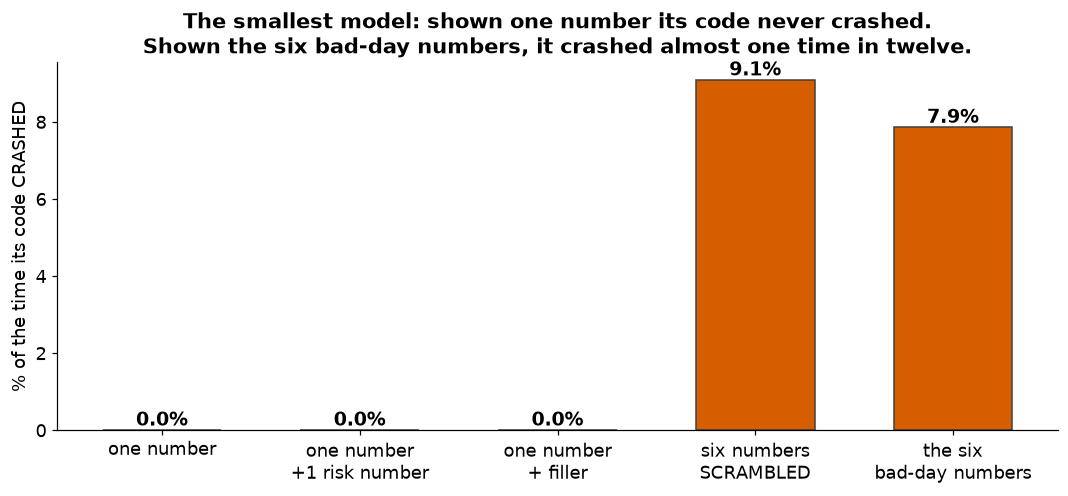

the only cells in the whole study with meaningful crash rates:
   qwen3_5_9b             placebo_shuffled       9.08%
   qwen3_5_9b             distributional         7.85%
   OPUS 5                 baseline_differential_downside_ratio   0.00%
   OPUS 5                 baseline_differential_sharpe   0.00%


In [9]:
byc = D[D.floor].groupby(["line", "arm"])["safe_default_rate"].mean()
nz = byc[byc > 1e-9]
tot_c, tot_d = int(D.safe_calls.fillna(0).sum()), int(D.safe_defaults.fillna(0).sum())
print("across the ENTIRE study:")
print("   times the AI-written code was run : {:,}".format(tot_c))
print("   times it crashed                  : {:,}".format(tot_d))
print("   cells (model x version) with ANY crashes: %d out of %d" % (len(nz), byc.size))
print()
worst = nz.sort_values(ascending=False)
mdl = worst.index[0][0]
fig, ax = plt.subplots(figsize=(9.6, 4.4))
arms = ["scalar", "scalar_cvar5", "placebo", "placebo_shuffled", "distributional"]
labs = ["one number", "one number\n+1 risk number", "one number\n+ filler", "six numbers\nSCRAMBLED", "the six\nbad-day numbers"]
vals = [100 * byc.get((mdl, a), 0.0) for a in arms]
bars = ax.bar(labs, vals, color=[GREY, GREY, GREY, RED, RED], edgecolor="0.25", width=0.6)
for b_, v in zip(bars, vals):
    ax.text(b_.get_x() + b_.get_width() / 2, v + 0.12, "%.1f%%" % v, ha="center", fontsize=12.5,
            fontweight="bold")
ax.set_ylabel("% of the time its code CRASHED", fontsize=12)
ax.set_title("The smallest model: shown one number its code never crashed.\nShown the six bad-day numbers, it crashed almost one time in twelve.",
             fontsize=13.5, fontweight="bold")
savefig(fig, FIG / "G8_code_crashes.png"); plt.show()
print("the only cells in the whole study with meaningful crash rates:")
for (l, a), v in worst.head(4).items():
    print("   %-22s %-20s %6.2f%%" % (name(l), a, 100 * v))

## WHAT IT MEANS

**This is the clearest single piece of evidence in the whole project.**

The smallest model, shown **one number**, wrote code that never crashed once. Shown **six numbers
about the bad days**, it wrote code that crashed nearly **one time in twelve**.

> **The failure is not that the weak model ignored the information. It is that the information
> pushed it into writing code it was not capable of writing correctly.**

Its portfolio then trained against a scoring rule that was silently falling back to a default a
twelfth of the time. No wonder the result was bad.

⚠ **And it does not explain everything, which you should say.** One other model also failed, and
**its code never crashed at all.** It wrote perfectly working code that optimised the wrong thing.
**Two models failed, in two different ways.** Offering one tidy explanation for both would be neater
and dishonest.

# 10. The three sub-questions

The main question breaks into three links in a chain. **We registered all three in advance**, so
that a negative result would tell us *where* the chain broke rather than just that it broke.

```
    what we show the AI  --(SQ1)-->  the CODE it writes  --(SQ2)-->  the result
                                                    (SQ3 checks it is real, not fake)
```

| | the sub-question in plain words | what we can say |
|---|---|---|
| **SQ1** | **Does what we show the AI change the code it writes?** | **Yes.** The code produced a measurably different portfolio: different trading rate, different losses, different crash size. It cannot have written the same code. |
| **SQ2** | **Does that change in the code reach the final outcome?** | **Yes.** The safer tail is a measured out-of-sample outcome, and it survived both control versions. |
| **SQ3** | **Is it genuine use of the information, or a surface trick?** | **Genuine.** A version with the same length and no information did not reproduce it, and neither did a version with one risk number. |

## ⚠ Be precise about what is and is not proved

**We answered all three by their outcomes, not by their dedicated instruments.**

The registration specifies particular tools for each: a responsiveness statistic for SQ1, a mediation
analysis for SQ2, and a structural code-comparison for SQ3. **Those have not been run yet.**

> **So the honest phrasing is: the evidence is consistent with all three links holding, and the
> dedicated instruments are the next step.** Saying that out loud will earn you more credit than
> claiming more than you have.

# 11. Every version, every number

**Nothing hidden.** This is every version on the main model, sorted best to worst.

In [10]:
COLS = {"sharpe": "Sharpe", "ann_return": "profit/yr", "oos_cvar_05": "worst-day loss",
        "max_drawdown": "worst crash", "turnover_mean": "traded per day",
        "sharpe_gross": "Sharpe before costs"}
t = (D[(D.line == "test") & D.floor].groupby("arm")
     .agg(runs=("seed", "count"), **{v: (k, "mean") for k, v in COLS.items()})
     .sort_values("Sharpe", ascending=False))
t.index = [i.replace("baseline_", "HUMAN: ") for i in t.index]
display(t.round(4))

,runs,Sharpe,profit/yr,worst-day loss,worst crash,traded per day,Sharpe before costs
HUMAN: return_minus_turnover,30,1.1609,0.1574,-0.0187,-0.1903,0.0077,1.1751
scalar_cvar5,30,1.1558,0.1580,-0.0187,-0.1851,0.0214,1.1951
placebo,30,1.1454,0.1522,-0.0183,-0.1893,0.0129,1.1700
scalar,30,1.1354,0.1614,-0.0195,-0.2013,0.0284,1.1860
placebo_shuffled,30,1.1047,0.1542,-0.0192,-0.2040,0.0328,1.1640
distributional,30,1.0527,0.1257,-0.0164,-0.1756,0.0570,1.1733
bayes_opt,30,1.0503,0.1248,-0.0163,-0.1725,0.0333,1.1208
random_search,30,0.9203,0.1044,-0.0155,-0.1658,0.0739,1.0859
tpe,30,0.8876,0.1181,-0.0184,-0.2089,0.1228,1.1176
cma_es,30,0.4391,0.0476,-0.0149,-0.1885,0.2613,1.0539


In [11]:
print("AND THE SAME FOR ALL TEN OTHER AI MODELS")
for line in LEGS:
    q = D[(D.line == line) & D.floor]
    g = (q.groupby("arm").agg(runs=("seed", "count"), **{v: (k, "mean") for k, v in COLS.items()})
         .sort_values("Sharpe", ascending=False))
    print("\n--- %s ---" % name(line))
    print(g.round(4).to_string())

AND THE SAME FOR ALL TEN OTHER AI MODELS

--- deepseek_v4_pro ---
                  runs  Sharpe  profit/yr  worst-day loss  worst crash  traded per day  Sharpe before costs
arm                                                                                                        
scalar              30  1.1781     0.1656         -0.0194      -0.1968          0.0076               1.1917
scalar_cvar5        30  1.1701     0.1638         -0.0194      -0.2003          0.0141               1.1954
distributional      30  1.1627     0.1651         -0.0195      -0.1987          0.0103               1.1812
placebo             30  1.1555     0.1627         -0.0195      -0.1954          0.0073               1.1687
placebo_shuffled    30  1.1181     0.1575         -0.0195      -0.1976          0.0211               1.1556

--- gemini_2_5_flash ---
                  runs  Sharpe  profit/yr  worst-day loss  worst crash  traded per day  Sharpe before costs
arm                                         

# 12. Why anyone should believe this

**This is your strongest card and most students do not have it.**

## We wrote the prediction down before we had any data

The study registered, in a file that was then cryptographically sealed, three possible outcomes and
predicted which one would happen. The prediction was:

> **the safety test would pass, and the profit test would not.**

**That is exactly what happened.** You can show the line in the file, and you can show the seal.

## The bar was set higher than it needed to be

The result had to beat **three** comparisons, not one, and all three at once. That rule was fixed in
advance. **A result that only had to beat the easy comparison would be far less convincing.**

## We ran it eleven times on eleven different models

The result is not a quirk of one AI product.

## We ran each version 30 times

Because the same code trained twice gives different answers. **Every number here is an average over
30 full training runs**, and every comparison is made run-by-run against its matched pair.

## The stopping date was fixed by the calendar

The campaign stops on **27 August** because that date was chosen in advance, not because the numbers
looked good. **Nobody could have stopped early on a favourable reading.**

# 13. What we cannot say yet

**Say these before you are asked. It reads as confidence, not weakness.**

1. **This is 30 runs, not the final count.** The campaign continues to 27 August. The direction is
   clear; the precision will improve.
2. **We cannot yet say the two versions are equivalent on profit.** Proving *no meaningful
   difference* needs about **112 runs** on this model. We have 30. We can say the safety difference
   is real; we cannot yet put a tight bound on the profit difference.
3. **One market, one period, one asset class.** UK and US equities, 2020 to mid-2026.
4. **Trading costs drive the human comparison.** Change the cost assumption and that ranking could
   change. We can test this without retraining anything, and have not yet.
5. **The dedicated mechanism instruments have not been run** (Section 10).
6. **The iteration result is explained but not proved** (Section 7).
7. **One model passed out of eleven.** We argue that is a capability effect and the evidence supports
   it, but with eleven models it remains an argument rather than a proof.

# 14. Your cheat sheet

## If you have thirty seconds

> **We asked an AI to write the scoring rule for a trading program, and we tested whether showing it
> the bad days changes what it writes. It does. The portfolio became measurably safer, with smaller
> losses on bad days and a smaller worst crash. It also made about three and a half per cent less
> profit a year. So the method works, and we can now say what it costs.**

## The five numbers to know by heart

| | |
|---|---|
| loss on the worst days | **1.64%** vs **1.95%** — safer |
| worst crash | **17.6%** vs **20.1%** — safer |
| profit per year | **12.6%** vs **16.1%** — lower |
| human rules that lose money after costs | **10 out of 11** |
| the weak model's code crash rate | **7.9%** vs **0%** |

## The four hard questions, and your answers

**"Lower Sharpe means it failed."**
It means it traded profit for safety. We measured both and reported both. Sharpe weights that trade
one way; a pension fund weights it another.

**"It was just longer text."**
We ran a same-length version with no information in it. The result beat it, with under a 1 in 10,000
chance of luck.

**"It only worked on one model."**
Yes, and that is the finding. The smallest model's code crashed 8% of the time when shown the same
information. Using a loss distribution is a capability.

**"Did you pick the test afterwards?"**
No. The prediction and the rule are on line 118 of a sealed file that predates the data.

## If you only show one picture

**Section 4b** — the one showing it beat all three comparisons. That single chart contains the
result and the defence of the result at the same time.